In [1]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.ticker as mticker

#Apply ggplot style to matplotlib plots for a clean, aesthetic look inspired by R's ggplot2.
plt.style.use('ggplot')  

#Import 'figure' function from matplotlib.pyplot to create new plot figures explicitly.
from matplotlib.pyplot import figure  

#Enable inline plotting in Jupyter notebooks, so plots appear directly below the code cells.
%matplotlib inline  

#Set default figure size for matplotlib plots to 12x8 inches, ensuring better visibility and readability.
matplotlib.rcParams['figure.figsize'] = (12,8)  

#Read the data from csv file.
df = pd.read_csv(r'C:\Users\adria\Downloads\archive\movies.csv')

In [2]:
#Check for missing values.

# Calculates the mean of True/False values where True means the value is missing (NaN) in this column.
# Prints the column name and the percentage of missing values rounded to nearest integer.
for col in df.columns:
    pct_missing = np.mean(df[col].isnull()) 
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [3]:
#In this case I decided to drop rows with missing data.
df = df.dropna()

In [4]:
# Check data types for columns
print(df.dtypes)

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object


In [5]:
#Change data types for more appropriate.
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['runtime'] = df['runtime'].astype('int64')
df['votes'] = df['votes'].astype('int64')

In [6]:
#Deleting potential duplicats
df.drop_duplicates(inplace=True)

In [7]:
#Reset index after row drops
df.reset_index(drop=True, inplace=True)

In [8]:
# Configure pandas to display all rows in the output, removing the default limit on the number of displayed rows for my convenience.
pd.set_option('display.max_rows', None)

# Sort the DataFrame by the 'gross' column in descending order without modifying the original DataFrame.
df.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
3731,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162
5302,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181
1795,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194
4730,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138
5158,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149
5334,The Lion King,PG,Animation,2019,"July 19, 2019 (United States)",6.9,222000,Jon Favreau,Jeff Nathanson,Donald Glover,United States,260000000,1670727580,Walt Disney Pictures,118
4720,Jurassic World,PG-13,Action,2015,"June 12, 2015 (United States)",7.0,593000,Colin Trevorrow,Rick Jaffa,Chris Pratt,United States,150000000,1670516444,Universal Pictures,124
4224,The Avengers,PG-13,Action,2012,"May 4, 2012 (United States)",8.0,1300000,Joss Whedon,Joss Whedon,Robert Downey Jr.,United States,220000000,1518815515,Marvel Studios,143
4713,Furious 7,PG-13,Action,2015,"April 3, 2015 (United States)",7.1,370000,James Wan,Chris Morgan,Vin Diesel,United States,190000000,1515341399,Universal Pictures,137
5346,Frozen II,PG,Animation,2019,"November 22, 2019 (United States)",6.8,148000,Chris Buck,Jennifer Lee,Kristen Bell,United States,150000000,1450026933,Walt Disney Animation Studios,103


In [9]:
# Normalize a categorical label
df['rating'].value_counts()

rating
R            2597
PG-13        1729
PG            907
G             111
Not Rated      44
Unrated        17
NC-17          12
TV-MA           2
Approved        1
X               1
Name: count, dtype: int64

In [10]:
# Change all Unrated to Not Rated
df['rating'] = df['rating'].replace({
    'Unrated': 'Not Rated'})
df['rating'].value_counts()

rating
R            2597
PG-13        1729
PG            907
G             111
Not Rated      61
NC-17          12
TV-MA           2
Approved        1
X               1
Name: count, dtype: int64

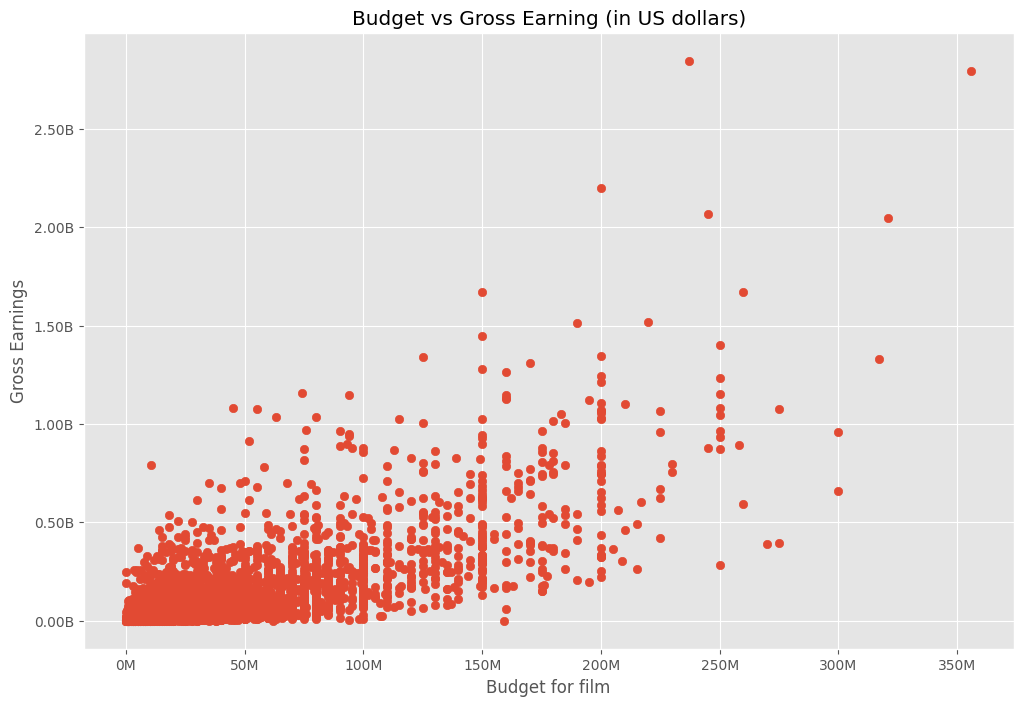

In [11]:
#Create a scatter plot visualizing the relationship between 'budget' and 'gross' earnings.
plt.scatter(x=df['budget'], y=df['gross'])
# Set the titles of the plot and labels axes to give context about what is being visualized.
plt.title('Budget vs Gross Earning (in US dollars)')
plt.ylabel('Gross Earnings')
plt.xlabel('Budget for film')

# Retrieve the current active axes object to modify axis properties directly.
ax = plt.gca()

# Apply a custom formatter to the x-axis ticks to display values in millions with 'M' suffix,
# converting the raw tick values by dividing by 1,000,000 for readability.
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-6:.0f}M'))

# Apply a custom formatter to the y-axis ticks to display values in billions with 'B' suffix,
# converting the raw tick values by dividing by 1,000,000,000 and formatting to two decimal places.
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*1e-9:.2f}B'))

# Display the plot so the visualization appears in the output.
plt.show()

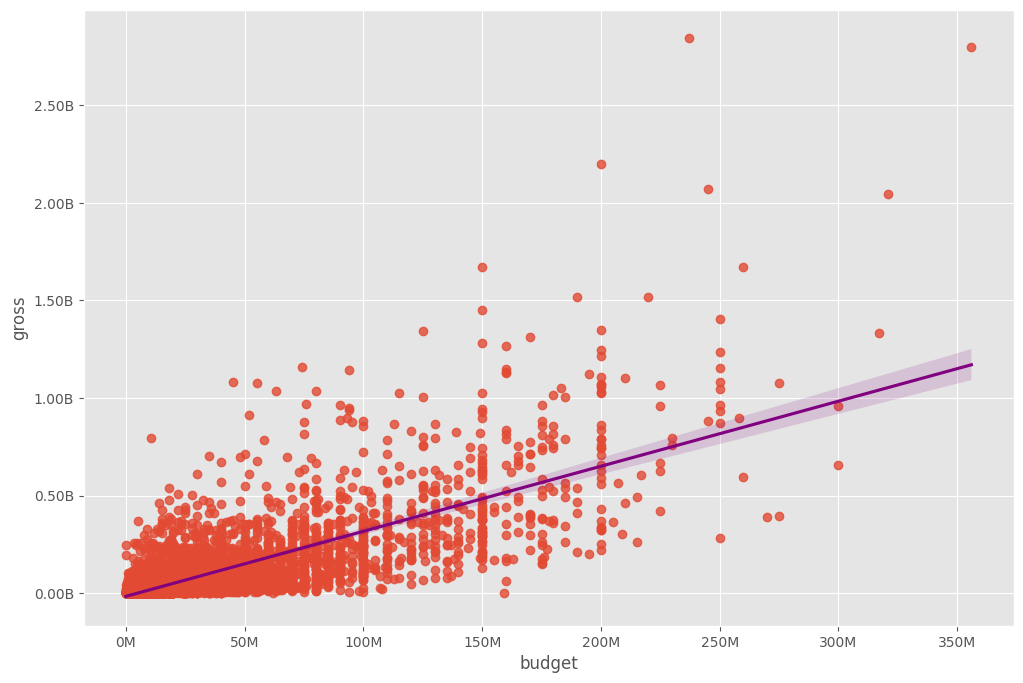

In [12]:
# Draw the regression plot
ax = sns.regplot(x="budget", y="gross", data=df, line_kws={"color":"purple"})

# Format x-axis ticks to show values in billions with a 'B' suffix
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-6:.0f}M'))

# Format y-axis ticks to show values in millions with 'M' suffix
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*1e-9:.2f}B'))

In [17]:
# Correlation Matrix between all numeric columns (Pearson by default)
df.corr(numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.056386,0.206021,0.327722,0.274321,0.075077
score,0.056386,1.000000,0.474256,0.072001,0.222556,0.414068
votes,0.206021,0.474256,1.000000,0.439675,0.614751,0.352303
budget,0.327722,0.072001,0.439675,1.000000,0.740247,0.318695
gross,0.274321,0.222556,0.614751,0.740247,1.000000,0.275796
runtime,0.075077,0.414068,0.352303,0.318695,0.275796,1.000000


In [18]:
# Flatten correlations to find strongest absolute pairs (exclude self-corr)
sorted_pairs = correlation_matrix.stack()

# Filter and view only stron correlations (abssolute value > 0.5 excluding self correlations)
strong_pairs = sorted_pairs[(abs(sorted_pairs) > 0.5) & (
    sorted_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)
strong_pairs

budget  gross    0.740247
votes   gross    0.614751
dtype: float64

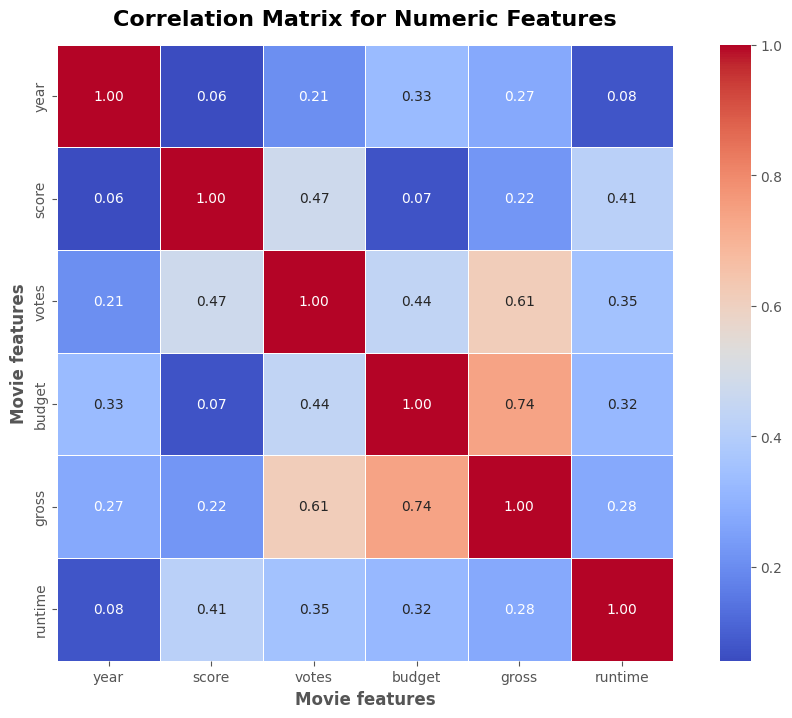

In [19]:
# Assign the correlation matrix to a variable for further use
correlation_matrix = df.corr(numeric_only=True)

# Visualize the correlation matrix as a heatmap for quick identification of strong and weak relationships
# The 'annot=True' parameter displays the correlation coefficients directly on the heatmap cells
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
            cmap='coolwarm', cbar=True, square=True, linewidths=0.5)

# Set the titles of the matrix and labels axes to give context about what is being visualized.
plt.title("Correlation Matrix for Numeric Features", fontsize=16, fontweight='bold', pad=14)
plt.xlabel("Movie features", fontweight='bold')
plt.ylabel("Movie features", fontweight='bold')

plt.show()

In [20]:
# Calculate the Profit for each movie
df['profit'] = df['gross'] - df['budget']

# Calculate the Return on Investement (ROI) for each movie
df['roi'] = (df['profit'] / df['budget']) * 100

df.style.format({"roi": "{:.1f}%"})

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,profit,roi
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146,27998772,147.361958
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104,54353106,1207.846800
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124,520375067,2890.972594
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88,79953539,2284.386829
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98,33846344,564.105733


Text(0, 0.5, 'Total Gross Revenue')

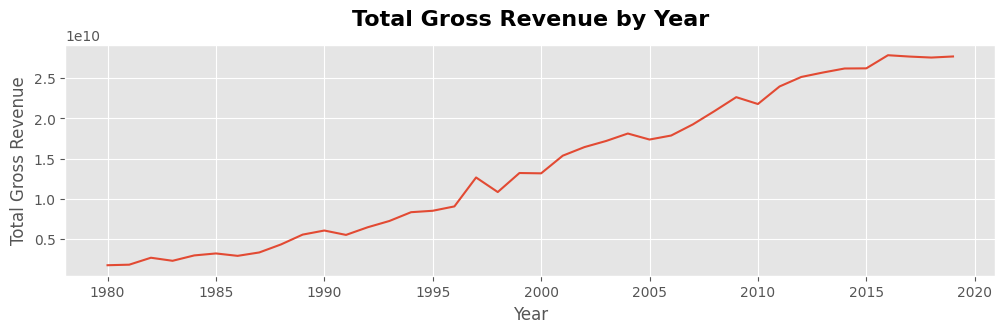

In [21]:
year_trend = df.groupby('year')['gross'].sum().reset_index()
year_trend = year_trend[year_trend['year'] != 2020]  # Exclude 2020 data

plt.figure(figsize=(12, 3))
sns.lineplot(
    x='year',
    y='gross',
    data=year_trend,
)
plt.title("Total Gross Revenue by Year",
          fontsize=16, fontweight='bold', pad=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Gross Revenue", fontsize=12)

In [22]:
#Summary statistics
total_movies = df['name'].count()
unique_genres = df['genre'].drop_duplicates().count()
average_budget = df['budget'].mean()
average_gross = df['gross'].mean()
average_roi = df['roi'].mean()
strongest_correlation = list(strong_pairs.index)[0]

linebreak = 30*"="

print(f"""{linebreak} SUMMARY STATISTICS {linebreak}
  - Total Movies: {total_movies:,.0f}
  - Unique Genres: {unique_genres:,.0f}
  - Average Budget: ${average_budget:,.0f}
  - Average Gross Revenue: ${average_gross:,.0f}
  - Average ROI: {average_roi:.1f}%
  - Strongest Correlation: {
      strongest_correlation[0].title()} and {
          strongest_correlation[1].title()} with a correlation of {
              strong_pairs[strongest_correlation]*100:.1f}%
{linebreak*3}
    """)

============================== SUMMARY STATISTICS ==============================
  - Total Movies: 5,421
  - Unique Genres: 15
  - Average Budget: $36,009,170
  - Average Gross Revenue: $103,229,653
  - Average ROI: 572.7%
  - Strongest Correlation: Budget and Gross with a correlation of 74.0%
    


In [23]:
#Top 5 Movies by Gross Revenue
top_5_roi = df.sort_values(by='gross', ascending=False).head()
top_5_roi[['name', 'rating', 'genre', 'budget', 'gross']
          ].reset_index(drop=True)

,name,rating,genre,budget,gross
0,Avatar,PG-13,Action,237000000,2847246203
1,Avengers: Endgame,PG-13,Action,356000000,2797501328
2,Titanic,PG-13,Drama,200000000,2201647264
3,Star Wars: Episode VII - The Force Awakens,PG-13,Action,245000000,2069521700
4,Avengers: Infinity War,PG-13,Action,321000000,2048359754


In [24]:
# Top 5 Earning Companies by Total Gross Revenue
top_companies = df.groupby('company')[['gross']].sum(
).sort_values(by='gross', ascending=False)
top_companies.head(5)

,gross
company,
Warner Bros.,54610959970
Universal Pictures,51241105418
Columbia Pictures,42356430218
Paramount Pictures,40021704691
Twentieth Century Fox,39542573303


In [25]:
#Most Successful Companies by Average Movie Revenue
avg_gross_companies = (
    df.groupby('company')['gross']
    .mean()
    .sort_values(ascending=False)
)

# Convert Series to DataFrame for better visualization
avg_gross_companies = avg_gross_companies.reset_index()
avg_gross_companies.columns = ['company', 'avg_gross_revenue']
avg_gross_companies.head(5)

,company,avg_gross_revenue
0,Marvel Studios,1.255466e+09
1,Illumination Entertainment,1.097122e+09
2,Fairview Entertainment,9.665549e+08
3,B24,8.806815e+08
4,Avi Arad Productions,8.560852e+08


In [26]:
#Which genres yield the highest ROI?
top_genres_roi = df.groupby('genre')['roi'].agg(
    ['mean', 'median']).sort_values(by='mean', ascending=False)
top_genres_roi.head(5)

,mean,median
genre,,
Horror,7667.151514,208.435407
Family,2013.018822,344.694169
Thriller,329.977546,270.223850
Animation,297.439888,191.990706
Drama,270.822576,52.643691


In [27]:
#Top Directors by Best Single-Movie Profit
top_directors = df[['director', 'name', 'profit']].loc[df.groupby(['director', 'name'])[
    'profit'].idxmax()].sort_values(by='profit', ascending=False).reset_index(drop=True)
top_directors.head(5)

,director,name,profit
0,James Cameron,Avatar,2610246203
1,Anthony Russo,Avengers: Endgame,2441501328
2,James Cameron,Titanic,2001647264
3,J.J. Abrams,Star Wars: Episode VII - The Force Awakens,1824521700
4,Anthony Russo,Avengers: Infinity War,1727359754
